# Graph Neural Networks for Flow Field Reconstruction

## Overview

This tutorial introduces **Graph Neural Networks (GNNs) for
Computational Fluid Dynamics (CFD)**. Rather than solving the governing PDEs numerically
at every time step, we train a GNN to approximate the solution update directly from the
mesh — dramatically reducing inference cost while preserving spatial fidelity on
unstructured grids.

### Learning Objectives

1. **Motivate** the use of GNNs for CFD by contrasting them with Convolutional Neural Networks (CNNs) and Multi-Layer Perceptrons (MLPs), and
   understand why the graph is a natural representation of an unstructured mesh.
2. **Load and inspect** a CFD dataset (NsCircle), understand its physical meaning, and
   construct a graph from the raw mesh using k-nearest-neighbour connectivity.
3. **Build and train** a single-scale GNN surrogate model and evaluate its rollout
   accuracy using the coefficient of determination R².
4. **Extend** the architecture to multi-scale (MuS-GNN), understand the DownMP/UpMP
   mechanism, and compare performance against the single-scale baseline.



### References

- Battaglia et al. (2018): Relational inductive biases, deep learning, and graph networks. https://arxiv.org/abs/1806.01261 
- Lino et al. (2022): Multi-scale rotation-equivariant graph neural networks for unsteady Eulerian fluid dynamics. https://pubs.aip.org/aip/pof/article/34/8/087110/2847850 


### Code

- Attapted from https://github.com/archied2804/graphs4cfd_cardiac, a fork from the graphs4cfd library developed by Mario Lino, https://github.com/mario-linov/graphs4cfd.


---

## Introduction and Theory


For the purpose of this tutorial we will use the formalism described by Battaglia et al., using a 'graph' to mean a "directed, attributed multi-graph with a global attribute".

Specifically, as in their notation, our graph data structure has the form $G = (\mathbf{u}, V, E)$, where $\mathbf{u}$ is our global attribute, $V = \{\mathbf{v}_i\}_{i=1:N^v}$ the set of node attributes attached to each node, and $E = \{(\mathbf{e}_k,r_k,s_k)\}_{k=1:N^e}$ the set of edges, each described by the coordinates of the send and receive nodes to which the said edge corresponds.

Traditional CFD methods (finite element, finite volume) discretise physical domains into meshes. Graph Neural Networks provide a natural framework for learning on these mesh-based representations:

- **Nodes** represent spatial locations (mesh vertices)
- **Edges** represent spatial relationships (connectivity)
- **Node features** encode physical quantities (velocity, pressure, etc.)
- **Edge features** encode geometric relationships (distance, relative positions)



### Pros and Cons of GNNs

#### Pros
- **Handles unstructured meshes natively** — works directly on the variable-topology meshes produced by CFD solvers, with no interpolation to a regular grid required.
- **Permutation invariant** — the result is independent of the arbitrary ordering of mesh nodes, which is a physically correct inductive bias for spatial problems.
- **Geometry-agnostic** — the same model can be applied to different geometries or mesh resolutions, making it straightforward to generalise across simulation parameters.
- **Scales with the mesh** — computational cost scales linearly with the number of nodes $N$ (rather than $N^2$ for attention-based approaches or $N^3$ for direct solvers), making it tractable on large engineering meshes.

#### Cons
- **Locality** — each message-passing step only propagates information one edge away; capturing long-range effects requires either many steps or a multi-scale architecture. This can be addressed with the MuS-GNN architecture in Section 6.


## 1. Theory — Why Graph Neural Networks for CFD?

### 1.1 The Problem with Standard Deep Learning on Meshes

Most deep learning surrogates for fluid dynamics use **Convolutional Neural Networks
(CNNs)**, which require data to live on a **structured Cartesian grid**. This is a
fundamental mismatch for CFD because:

- Real geometries (aerofoils, cylinders, turbine blades) require **unstructured meshes**
  with variable local resolution — finer near walls, coarser in the freestream.
- The mesh topology changes between training samples as geometry parameters vary.
- Interpolating an unstructured mesh onto a grid destroys precision near boundaries,
  exactly where the physics is most complex.

**Graph Neural Networks (GNNs)** resolve this by treating the mesh **as-is**:

| Mesh concept              | Graph concept                        |
|---------------------------|--------------------------------------|
| Mesh vertex               | Node  $v_i$                          |
| Mesh connectivity         | Directed edge  $e_{ij}$              |
| Physical fields (u, v, p) | Node features  $\mathbf{f}_i$        |
| Relative node positions   | Edge features  $\mathbf{r}_{ij}$     |



<p align="center">
  
![image.png](attachment:image.png)

</p>

---

### 1.2 Inductive Biases

Every neural architecture encodes **prior assumptions** — called inductive biases —
about what structure the data has. The right bias enables quicker learning; the wrong one
forces the network to waste resources and increases complexity fighting the architecture.

| Architecture      | What are the entities? | How do they relate?  | Key inductive bias                         |
|-------------------|------------------------|----------------------|--------------------------------------------|
| Fully connected   | Scalar units           | All-to-all           | None — maximum flexibility, maximum data need |
| CNN               | Grid pixels            | Local neighbours     | Translation invariance + spatial locality  |
| RNN               | Time steps             | Sequential           | Temporal invariance                        |
| **GNN**           | **Nodes on a graph**   | **Arbitrary edges**  | **Permutation invariance + relational locality** |

For CFD, the physics satisfies both GNN biases naturally:

- **Relational locality** — a node's state is directly influenced only by its immediate
  mesh neighbours in one time step (the PDE stencil is local).
- **Permutation invariance** — the numbering of mesh nodes is arbitrary; the physics is
  the same regardless of the order you process them.

---

### 1.3 The GNN as a Learned Time-Stepper

The flow fields in this tutorial are governed by the **incompressible Navier–Stokes
equations**:

$$\frac{\partial u}{\partial t} + (\mathbf{u} \cdot \nabla)\mathbf{u} =
-\nabla p + \frac{1}{Re}\nabla^2 \mathbf{u}, \qquad \nabla \cdot \mathbf{u} = 0$$

where $\mathbf{u} = (u, v)$ is the velocity vector field and $p$ is pressure.

Rather than solving these equations numerically, the GNN learns to approximate the
**time-integral** at each mesh node:

$$I_i = \int_{t_0}^{t_0 + \Delta t} F(\mathbf{u}, Re) \, \mathrm{d}t
\bigg|_{\mathbf{x}_i}$$

The solution is advanced by the simple residual update:

$$\mathbf{u}^{t_0 + \Delta t}(\mathbf{x}_i)
= \mathbf{u}^{t_0}(\mathbf{x}_i) + I_i$$

This update can be applied **autoregressively** — the predicted state is fed back as
input to produce a temporal rollout of arbitrary length. The GNN therefore acts as a
fast surrogate for the numerical solver.

> **Key advantage:** the GNN time step $\Delta t$ can be far larger than the CFL-limited
> step of an explicit solver, since the network is not subject to numerical stability
> constraints.


# Importing Libraries and Data

This tutorial will be developed using the PyG (Pytorch Geometric) Library built upon PyTorch.

PyTorch - https://pytorch.org/ 

PyTorch Geometric - https://pytorch-geometric.readthedocs.io/en/latest/

From this the attached library ```GNN_4_CFD``` has been built, this has been developed using the code from [Mario Lino](https://pubs.aip.org/aip/pof/article/34/8/087110/2847850/Multi-scale-rotation-equivariant-graph-neural), built for his work developing Rotationally-Equivarient GNNs.

For a full understanding of the code reading through the code in the ```GNN_4_CFD``` library, namely the GNN class in ```./GNN_4_CFD/nn/model.py``` for an understanding of the implementation of the training loop

```
.
├── GNN_4_CFD/
│   ├── __init__.py
│   ├── cfd_dataset.py
│   ├── data_loader.py
│   ├── graph.py
│   ├── metrics.py
│   ├── nn/
│   │   ├── __init__.py
│   │   ├── blocks.py
│   │   ├── GNN_Architect.py
│   │   ├── losses.py
│   │   ├── model.py
│   │   └── UniversalGNN.py
│   ├── process/
│   │   ├── __init__.py
│   │   ├── plot.py
│   │   ├── plot_training.py
│   │   └── tensorboard_log.py
│   ├── data/
│   │   └── NsCircle
│   │       ├── test
│   │       │   ├── NsCircleHighRe.h5
│   │       │   ├── NsCircleMidRe.h5
│   │       │   └── NsCircleLowRe.h5
│   │       ├── train
│   │       │   └── NsCircle.h5
│   │       └── README.txt
│   └── transforms/
│       ├── __init__.py
│       ├── connect.py
│       ├── geometric.py
│       ├── ms_clustering.py
│       ├── noise.py
│       └── scale.py
├── GNN_Tutorial_AIRTUK.ipynb
├── pyproject.toml
└── README.md
```


## 1. Libraries

In [1]:
# Check running in the correct venv
import sys
print(sys.executable)

/home/y95228da/.airtuk/envs/airtuk/bin/python


In [2]:
# Import necessary libraries
import glob
import os
import gc
import torch
import torch_geometric
from torchvision import transforms
import numpy as np
import GNN_4_CFD as gfd
import matplotlib.pyplot as plt

In [3]:
# Check if GPU is available and set device accordingly
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Device:', device, 'is being used')

Device: cuda:0 is being used


## 2. Data Representation — NsCircle Dataset

The dataset is generated with **Nektar++**, a spectral/hp element solver, for 2D incompressible Navier–Stokes flow past a **circular cylinders** at a range or $Re$ and vertical postitions.

Links to datasets

- Primary dataset - https://zenodo.org/records/7870707
- Secondary dataset (if first isn't available)- https://huggingface.co/datasets/mariolinov/Ellipse/tree/main


> **Physical picture:** Fluid enters from the left at unit velocity. As it passes the cylinders, it separates and forms a periodic wake — the classical **Kármán vortex street**. The GNN learns to predict how this flow field evolves from one snapshot to the next.

### Simulation Parameters

| Parameter                    | Value / Range                         |
|------------------------------|---------------------------------------|
| Cylinder diameter $D$        | 1 (normalised)                        |
| Centre-to-centre spacing $H$ | Randomly sampled $\in [4D,\, 6D]$     |
| Reynolds number $Re$         | $\in [500,\, 1000]$ — laminar shedding|
| Training simulations         | ~1000 independent cases               |
| Nodes per mesh               | ~7000                                 |
| Time step $\Delta t$         | 0.1                                   |
| Snapshots per simulation     | 100 (after periodic steady-state)     |

### State Variables

Each graph node stores three fields at each snapshot:

- $u$ — horizontal (streamwise) velocity
- $v$ — vertical (cross-stream) velocity
- $p$ — pressure

The Reynolds number $Re$ is broadcast as an additional **node-level scalar**, giving the network information about the current flow regime.

### Boundary Conditions

| Boundary       | Condition                                                   |
|----------------|-------------------------------------------------------------|
| Inlet (left)   | Dirichlet: $u = 1$, $v = 0$                                 |
| Outlet (right) | Outflow: $\partial u/\partial x = \partial v/\partial x = 0$, $p = 0$ |
| Top / Bottom   | **Periodic** — flow cycles vertically                       |
| Cylinder walls | No-slip: $u = v = 0$                                        |

A binary flag $d_i \in \{0, 1\}$ is stored per node ($d_i = 1$ on any Dirichlet boundary) so the model knows which nodes are constrained and should not be updated.


### 2.1 Graph Construction from the Mesh

The mesh vertices become **graph nodes**. Edges are built using a **k-Nearest Neighbours (kNN)** algorithm with $k = 6$: each node receives exactly 6 incoming directed edges from its spatially closest neighbours.

**Why fix $k = 6$?**
A fixed in-degree ensures every message-passing step has **uniform computational cost** regardless of local mesh density. It also improves training stability by preventing high-degree hub nodes from dominating the aggregation. However the actual number of nearest neighbors, $k$, can be changes as a training hyperparameter.\

**Edge features** encode the *relative position* of the sender with respect to the receiver:

$$\mathbf{r}_{ij} = \mathbf{x}_j - \mathbf{x}_i \in \mathbb{R}^2$$

This is **translation-invariant** by construction — the edge feature depends only on the
displacement between nodes, not their absolute coordinates.

**Feature normalisation** is applied before training to bring all inputs into a
comparable range:

| Feature          | Normalisation                                            |
|------------------|----------------------------------------------------------|
| $u,\, v,\, p$    | Linear rescaling to $[-1, 1]$ using training dataset min/max |
| $Re$             | Linear rescaling to $[-1, 1]$                            |
| Edge lengths     | Divided by 0.1 so typical values are $\mathcal{O}(1)$   |

In the code, these are applied via `transforms.Compose`:
```python
transform = transforms.Compose([
    gfd.transforms.ConnectKNN(6, period=[None, "auto"]),  # build the graph
    gfd.transforms.ScaleNs({...}, format='uvp'),          # normalise node features
    gfd.transforms.ScaleEdgeAttr(0.1),                    # normalise edge features
])


## 3. Visualising the Data

First we load the dataset in

In [ ]:
import requests
from pathlib import Path
import zipfile

record_id = 7870707
api = f"https://zenodo.org/api/records/{record_id}"
metadata = requests.get(api).json()
# Find NsCircle.zip
for f in metadata["files"]:
    if f["key"] == "NsCircle.zip":
        download_url = f["links"]["self"]
        break
else:
    raise RuntimeError("NsCircle.zip not found in Zenodo record.")

# Create data directory
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

zip_path = data_dir / "NsCircle.zip"

# Download zip file if not already present
if not zip_path.exists():
    print("Downloading NsCircle.zip ...")
    with requests.get(download_url, stream=True) as r:
        r.raise_for_status()
        with open(zip_path, "wb") as fp:
            for chunk in r.iter_content(1024 * 1024):
                fp.write(chunk)
    print("Download completed.")
else:
    print("Zip file already exists.")

# Extract zip file
extract_dir = data_dir / "NsCircle"

if not extract_dir.exists():
    print("Extracting NsCircle.zip ...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction completed.")
else:
    print("Files already extracted.")

# List extracted files
for f in extract_dir.rglob("*"):
    if f.is_file():
        print(f)

In [ ]:
# Define the path to the training data
path_to_data = "./data/NsCircle/train/NsCircle.h5"

# Setup your training info:
#   n_in    : Time step to start from (e.g., how many time steps to use as input for the model)
#   n_out   : Time step to predict (e.g., how many time steps to predict into the future)
#   step    : Time step size for the simulation 
#   T       : Total number of time steps in the dataset
info = {"n_in": 1, "n_out": 1, "step": 1, "T": 200}

# Initialise dataset
data = gfd.cfd_dataset.NsEllipse('uvp', path=path_to_data, training_info=info)

print(f'Number of samples in dataset provided: {len(data)}')

Then we can visualise the shape of the dataset and the data structures it contains, for more information on how this is read in see ```GNN_4_CFD/cfd_dataset.py```

In [ ]:
# 1. Quick readout
print(data) 
# Output: <NsEllipse (samples=N, path=data.h5)>

# 2. Detailed structure readout
data.summary()


Now we can visualise the flow fields

In [ ]:
# Picks the first frame of the first sample in the dataset
# Change the indices to access different samples and time steps (e.g., data.get_sequence(sample_index (simulation index), time_step_index))
graph = data.get_sequence(1031,6)

# Plot the fields (u, v, p) contained in the dataset
print("u - the x-velocity field of the fluid flow")
gfd.process.plot.field(graph.pos, graph.target[:,0], bound=graph.bound)
print("v - the y-velocity field of the fluid flow")
gfd.process.plot.field(graph.pos, graph.target[:,1], bound=graph.bound)
print("p - the pressure field of the fluid flow")
gfd.process.plot.field(graph.pos, graph.target[:,2], bound=graph.bound)

# Plot the nodes of the graph colored by the field value
print("Nodes colored by the x-velocity field (u)")
print(graph.pos.shape) # Output: torch.Size([N, 2]) where N is the number of nodes
gfd.process.plot.pos_field(graph.pos, graph.target[:,0])

# Using the Code

## 4. Network Architecture

The network architecture used in this tutorial is built on the Graph Network formulation described by Battaglia et al. (2018), *Relational inductive biases, deep learning, and graph networks*, [arXiv:1806.01261](https://arxiv.org/abs/1806.01261).


### 4.1. The Encode-Process-Decode Workflow


```markdown
Input node features  →  [Node MLP Encoder]  →  latent vᵢ   (size: hidden_dim)
Input edge features  →  [Edge MLP Encoder]  →  latent eᵢⱼ  (size: hidden_dim)
                                │
                      ┌─────────▼─────────┐
                      │    GN Block × M    │
                      │  ① Edge update     │
                      │  ② Aggregate       │
                      │  ③ Node update     │
                      └─────────┬─────────┘
                                │
                      [Node MLP Decoder]  →  predicted Iᵢ
```



### 4.2. The Graph Network (GN) Block

The GN block is the engine of the network, defining how information moves between nodes (points), edges (connections), and global attributes (the whole system). It uses a two-step MLP process:

- Edge Update ($\phi^e$): Computes the "message" or signal passing between two nodes based on their current states and any global influences.
- Aggregation ($\rho^{e \rightarrow v}$): Collects all incoming messages for a node. Crucially, this step is permutation-invariant, meaning the result is independent of the order in which neighbor data is processed.
- Node Update ($\phi^v$): Updates the node's properties (e.g., velocity) based on its previous state and the aggregated messages.

\[
\begin{aligned}
e'_k &= \phi^e(e_k, v_{r_k}, v_{s_k}, u) \\
v'_i &= \phi^v(\bar{e}'_i, v_i, u) \\
u'   &= \phi^u(\bar{e}', \bar{v}', u) \\
\bar{e}'_i &= \rho^{e \rightarrow v}(E'_i) \\
\bar{e}'   &= \rho^{e \rightarrow u}(E') \\
\bar{v}'   &= \rho^{v \rightarrow u}(V')
\end{aligned}
\]

In this tutorial the global attribute $u$ is unused (no global-level update), so the equations simplify to the edge and node updates only.


### 4.3. The MLP Architecture in Each Block

Every $\phi^e$ (edge update) and $\phi^v$ (node update) function is implemented as a small Multi-Layer Perceptron (MLP). In `GNN_4_CFD/nn/blocks.py`:

- **Activation:** **SELU** (Scaled Exponential Linear Unit) is used after every hidden linear layer. SELU has the useful property of self-normalising activations, which stabilises training on deep networks without requiring batch normalisation.
- **Layer normalisation:** An optional `LayerNorm` is applied to the output of the final linear layer. This is enabled on encoders (off by default on MP blocks) to keep latent representations centred.
- **No output activation:** The last linear layer has no activation, preserving the sign and magnitude of the output.
- **Depth and width:** Controlled by `mlp_depth` (number of hidden layers) and `hidden_dim` (number of neurons per layer). Both are set globally in `arch_parameters`.

A typical block MLP with `mlp_depth=3` and `hidden_dim=128` has the shape:

```
Linear(in → 128) → SELU → Linear(128 → 128) → SELU → Linear(128 → 128) → SELU → Linear(128 → out)
```

The **residual structure** of the GNN comes not from skip connections inside the MLP, but from the autoregressive time-stepper: the network predicts a *correction* $I_i$ which is added to the previous state, rather than predicting the absolute next state.


### 4.4. Multi-scale Architectures

To handle large systems efficiently, the MuS-GNN creates lower-resolution versions of the graph. By "coarsening" the data into smaller subsets, the network can pass messages over greater distances more quickly, capturing both fine-grained details and big-picture trends.

<p align="center">

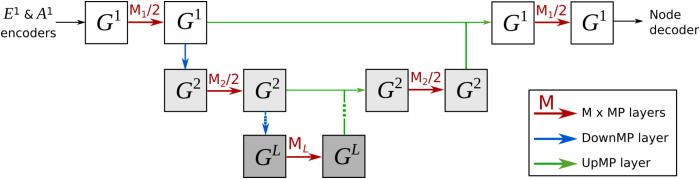

</p>


```markdown
G¹  fine     (~7k nodes)        
                         ──[MP]──► [DownMP] ──────────────────────► [UpMP] ──[MP]──► Decode

G²  coarser  (~1.7k nodes)            
                            ────────► [MP] ──► [DownMP] ──► [UpMP] ◄────────

G³  coarsest (~400 nodes)                     
                                        ────────► [MP] ◄──────────────
```


The coarser graphs enables **long-range communication**: information travels many effective hops on the fine mesh in a single MP step on a coarse graph, because each coarse node represents a cluster of fine nodes.

**DownMP — fine to coarse:**

Each coarse node $j \in V^\ell$ aggregates features from its **child nodes** $\mathrm{Ch}(j) \subset V^1$ (the fine nodes that fall within its grid cell):

$$\mathbf{v}^\ell_j = \frac{1}{|\mathrm{Ch}(j)|}
\sum_{i \in \mathrm{Ch}(j)}
f^{1 \to \ell}\!\left(\mathbf{r}^{1\to\ell}_{ij},\; \mathbf{v}^1_i\right)$$

**UpMP — coarse to fine:**

Each fine node $j$ is updated using its own latent feature and the feature of its parent coarse node $i \in V^\ell$:

$$\mathbf{v}'_j = f^{\ell \to 1}\!\left(
  \mathbf{r}^{\ell \to 1}_{ij},\; \mathbf{v}^\ell_i,\; \mathbf{v}^1_j
\right)$$

**Coarse graph construction** uses `GridClustering`: the domain is partitioned into a regular grid with cell size $d^\ell$, and one coarse node is placed at the mean position of all fine nodes in each occupied cell.

```python
# Resolutions [0.15, 0.30] → 3 scales (fine + 2 coarse), compression ~4× per level
gfd.transforms.GridClustering([0.15, 0.30])
```



### 4.5 The GNN_4_CFD Implementation of This

The library is structured to separate concerns cleanly:

```
.
├── GNN_4_CFD/
│   ├── __init__.py
│   ├── cfd_dataset.py
│   ├── data_loader.py
│   ├── graph.py
│   ├── metrics.py
│   ├── nn/
│   │   ├── __init__.py
│   │   ├── blocks.py
│   │   ├── GNN_Architect.py
│   │   ├── losses.py
│   │   ├── model.py
│   │   └── UniversalGNN.py
│   ├── process/
│   │   ├── __init__.py
│   │   ├── plot.py
│   │   ├── plot_training.py
│   │   └── tensorboard_log.py
│   ├── data/
│   │   └── NsCircle
│   │       ├── test
│   │       │   ├── NsCircleHighRe.h5
│   │       │   ├── NsCircleMidRe.h5
│   │       │   └── NsCircleLowRe.h5
│   │       ├── train
│   │       │   └── NsCircle.h5
│   │       └── README.txt
│   └── transforms/
│       ├── __init__.py
│       ├── connect.py
│       ├── geometric.py
│       ├── ms_clustering.py
│       ├── noise.py
│       └── scale.py
├── GNN_Tutorial_AIRTUK.ipynb
├── pyproject.toml
└── README.md
```



**Key classes to understand:**

| Class / File | Role |
|---|---|
| `nn/blocks.py` — `GNBlock` | Implements one GN block: edge MLP → aggregate → node MLP |
| `nn/GNN_Architect.py` — `GNNArchBuilder` | Stacks $M$ GN blocks with encoder/decoder into a full architecture dict |
| `nn/GNN_Architect.py` — `MultiScaleGNNBuilder` | Extends `GNNArchBuilder` with DownMP/UpMP inter-scale connections |
| `nn/model.py` — `GNN` | Base class with `.fit()`, `.solve()`, checkpoint/resumption logic |
| `nn/UniversalGNN.py` — `UniversalGNN` | Wraps an architecture dict into a trainable PyTorch module |
| `transforms/connect.py` — `ConnectKNN` | Computes k-NN edges and sets `edge_attr = xⱼ − xᵢ` |
| `transforms/ms_clustering.py` — `GridClustering` | Builds the multi-scale graph hierarchy at batch time |




# 5 Single Scale GNN Implementation

To be used to understand the setup of the training model on a smaller model, before moving onto using the MultiScale architectures defined above.

- How to build architectures and what these represent
- Understand the loss functions and training parameters
- Utilise transforms and DataLoader to batch training data
- Training procedure
- Simple postprocessing

Move onto the MultiScale architectures for improved results

## 5.1. Defining the Single Scale Model Architecture

In [ ]:
# Model definition 
#   num_mp_blocks: Number of message-passing blocks in the GNN architecture
#   hidden_dim: Width of the MP blocks layers
#   edge_encoder_in: Input dimension for the edge encoder (e.g., number of edge features)
#   node_encoder_in: Input dimension for the node encoder (e.g., number of node features)
#   decoder_out: Output dimension for the decoder (e.g., number of target fields to predict)
#   mlp_depth: Depth of the MLP used in the GNN architecture (e.g., number of layers in the MLP)

arch_parameters = {
    "num_mp_blocks": 8,
    "hidden_dim": 128,
    "edge_encoder_in": 2,
    "node_encoder_in": 5,
    "decoder_out": 3,
    "mlp_depth": 3
}

print("-"*60)
print("SINGLE-SCALE GNN EXAMPLE")
print("-"*60)

# Build single-scale GNN using the architecture defined above
builder = gfd.nn.GNN_Architect.GNNArchBuilder(arch_parameters)

print(builder.summary())
arch = builder.build_single_scale()

print("\nGenerated architecture keys:")
for key in arch:
    print(f"  {key}: {arch[key]}")


## 5.2. Define the Training Configuration

The `TrainConfig` object controls the entire training procedure. Each parameter has a
specific purpose:

#### Loss Function — `GraphLoss(lambda_d=0.25)`

The training loss combines L2 and L1 terms over all nodes:

$$\mathcal{L}(\theta) =
\underbrace{\sum_{i} \left\| \hat{u}_i - u^*_i \right\|_2^2}_{\text{L2 term}}
+ \lambda_d \underbrace{\sum_{i} \left| \hat{u}_i - u^*_i \right|}_{\text{L1 term}}$$


The term ($\lambda_d = 0.25$) is applied to the loss on the dirichelet boundary, that is on the surface of the cylinder to encourage the models to improve the physical correclation of the near wall flow.

#### Multi-Step Rollout Curriculum — `num_steps` and `add_steps`

Training on **single-step predictions** alone produces models that accumulate large
errors during rollout — the model is never exposed during training to inputs that
deviate from the ground truth, so small errors compound.

The fix:

1. Start training with 1 autoregressive rollout step.
2. When the training loss drops below `tolerance = 0.005`, increase to 2 steps.
3. Continue until the maximum of 10 steps is reached.

```python
num_steps = [i for i in range(1, 11)],   # [1, 2, 3, ..., 10]
add_steps = {'tolerance': 0.005, 'loss': 'training'}
```

In [ ]:
# Example training configuration and naming scheme

test_id = 1
model_name = f"GNN_SINGLE_SCALE_TEST_{test_id:02d}"
print(model_name)

# Training configuration
train_config = gfd.nn.TrainConfig(
    name            = model_name,
    folder          = './checkpoints',                                              # Folder to save model checkpoints 
    tensor_board    = './logs',                                                     # Folder to save tensorboard logs
    chk_interval    = 1,                                                            # Checkpoint saving interval (e.g., save a checkpoint every n epochs)
    training_loss   = gfd.nn.losses.GraphLoss(lambda_d=0.25),                       # Loss function for training (can define losses in gfd.nn.losses)
    validation_loss = gfd.nn.losses.GraphLoss(),                                    # Loss function for validation (can define losses in gfd.nn.losses)
    epochs          = 2,
    num_steps       = [i for i in range(1,11)],                                     # Time steps to predict (e.g., predict from 1 to 10 time steps into the future)
    add_steps       = {'tolerance': 0.005, 'loss': 'training'},
    batch_size      = 1,                                                            # Batch size OR number of samples to use in each training iteration
    lr              = 1e-5,                                                         # Learning rate 
    grad_clip       = {"epoch": 0, "limit": 1},                                     # Gradient clipping configuration (e.g., clip gradients to a maximum norm of 1)
    scheduler       = {"factor": 0.5, "patience": 5, "loss": 'training'},           # Learning rate scheduler configuration (e.g., reduce lr by a factor of 0.5 if. no loss improvement for 5 epochs)
    stopping        = 1e-8,                                                         # Early stopping
    mixed_precision = True,                                                         # Use mixed precision training (can speed up training and reduce memory usage on compatible hardware)
    device          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # Device to train on (e.g., 'cuda' for GPU or 'cpu' for CPU
)

## 5.3. Loading Data

### 5.3.1 Training and Validation Data

- Locate dataset
- Apply necessary transforms
- Split into training and validation sets

In [ ]:
# Training datasets
path_to_ellipse_data = "./data/NsCircle/train/NsCircle.h5"  # full datasets at https://zenodo.org/records/7870707 or https://huggingface.co/datasets/mariolinov/Ellipse/tree/main

# Transforms to apply to the data
transform = transforms.Compose([
    # Connect each node to its 6 nearest neighbours, period enforces correct clustering at the boundaries.
    gfd.transforms.ConnectKNN(6, period=[None, "auto"]),

    # Normalise the fields using the min and max values of the training dataset.
    gfd.transforms.ScaleNs({'u': (-2.1,2.6), 'v': (-2.25,2.1), 'p': (-3.7,2.35), 'Re': (500,1000)}, format='uvp'),

    # Scale the edge attributes (e.g., the distance between nodes) to a smaller range to improve training stability
    gfd.transforms.ScaleEdgeAttr(0.1),

    # Additional data augmentation transforms (uncomment to apply) see https://github.com/mario-linov/graphs4cfd for implementation details
    # gfd.transforms.RandomGraphRotation(eq='ns', format='uvp'),
    # gfd.transforms.RandomGraphFlip(eq='ns', format='uvp'),
    # gfd.transforms.AddUniformNoise(0.01)
])

# Initialise the dataset with the defined transforms (this will apply the transforms to each sample when accessed, you can set preload=True to apply the transforms to the entire dataset at once if you have enough memory)

dataset = gfd.cfd_dataset.NsEllipse(format='uvp', path=path_to_ellipse_data, training_info={"n_in":1, "n_out":train_config['num_steps'][-1], "step":1, "T":100}, transform=transform) # If enough memory, set preload=True

# Training testing data split
train_set, test_set = torch.utils.data.random_split(dataset, [0.9,0.1])

# Create data loaders for training and validation datasets (this will handle batching and shuffling of the data during training)
train_loader = gfd.DataLoader(
    train_set,
    batch_size  = train_config['batch_size'],
    shuffle     = True,
    num_workers = 8 # More CPU Nodes allows for faster data loading (e.g., applying transforms in parallel)
)   
val_loader  = gfd.DataLoader(
    test_set, 
    batch_size  = train_config['batch_size'],
    shuffle     = False,
    num_workers = 8
)   

### 5.3.2 Test Data

In [ ]:
# NsCircle dataset (training dataset)

# Define the scaling for the fields based on the min and max values in the training dataset.

scaling = {'u': (-2.1,2.6), 'v': (-2.25,2.1), 'p': (-3.7,2.35), 'Re': (500,1000)} # This tuples are the (min, max) values for each variable in the training dataset

# Define the transforms to apply to the data .
transform = transforms.Compose([
    # Connect each node to its 6 nearest neighbours, period enforces correct clustering at the boundaries.
    gfd.transforms.ConnectKNN(6, period=(None,"auto")),
    # Normalise the fields using the min and max values of the training dataset.
    gfd.transforms.ScaleNs(scaling, 'uvp'),
    # Scale the edge attributes (e.g., the distance between nodes) to a smaller range to improve training stability
    gfd.transforms.ScaleEdgeAttr(0.1),
])

# NsCircleMidRe dataset (Testing dataset at in range Reynolds number)
path_to_validation = "./data/NsCircle/test/NsCircleMidRe.h5"

# Initialise the validation dataset with the same transforms as the training dataset.
ns_valid = gfd.cfd_dataset.NsEllipse('uvp', path=path_to_validation, transform=transform) # The format is 'uvp' because the dataset contains the velocity components and the pressure


# Print the number of samples/simulations in each dataset
print(f'Number of samples in ns_circle: {len(ns_valid)}')

## 5.4. Training the Model

In [ ]:
# Select device and configure CPU/GPU resources
if torch.cuda.is_available():
    device = torch.device("cuda")
    n_gpus = torch.cuda.device_count()

    print(f"Using GPU: {n_gpus} available")
    for i in range(n_gpus):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

else:
    device = torch.device("cpu")

    # Configure CPU parallelism
    n_cpus = os.cpu_count()
    print(f"Using CPU ({n_cpus} cores available)")

    # Adjust these depending on Slurm allocation
    torch.set_num_threads(32)
    torch.set_num_interop_threads(8)

    print("PyTorch CPU threads:", torch.get_num_threads())
    print("PyTorch interop threads:", torch.get_num_interop_threads())

print("Selected device:", device)

# Clear memory
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

    for i in range(torch.cuda.device_count()):
        with torch.cuda.device(i):
            torch.cuda.reset_peak_memory_stats()
# Build the model
model = gfd.nn.UniversalGNN(arch=arch)

# Move model to selected device (if supported by the model)
model = model.to(device)
print("Number of trainable parameters:", model.num_params)

# Apply the training loop
os.makedirs("./checkpoints", exist_ok=True)
model.fit(train_config, train_loader, val_loader=val_loader)

## 5.5. Post Processing the Single Scale Results

### 5.5.1 Training and Validation Loss Plot (Training Plot)

In [ ]:
# Find most recent events.out file produced

# Path to logs file
log_dir = f"./logs/{model_name}/"
event_files = glob.glob(os.path.join(log_dir, "events.out.tfevents.*"))

# Find the most recent events.out file based on modification time
most_recent_tensorboard_log = max(event_files, key=os.path.getmtime)
data = gfd.process.read_tensorboard_logs(most_recent_tensorboard_log)

# Manual pointing to tensorboard output

# path_to_tensorboard = "/path/to/event*"
# data = gfd.process.read_tensorboard_logs(path_to_tensorboard)

gfd.process.plot_losses(data)

### 5.5.2 Field Extrapolation


### Results — Coefficient of Determination R²

Model accuracy is reported using the **coefficient of determination** $R^2$, computed
node-wise over the full rollout:

$$R^2 = 1 - \frac{\displaystyle\sum_{i,\,t}
  \left(\hat{u}_{i,t} - u^*_{i,t}\right)^2}
{\displaystyle\sum_{i,\,t}
  \left(u^*_{i,t} - \bar{u}^*\right)^2}$$

where $\bar{u}^*$ is the mean of the ground-truth field over all nodes and time steps.

$R^2$ is computed **separately** for each field ($u$, $v$, $p$) by slicing the interleaved
output tensor (columns `0::3` for $u$, `1::3` for $v$, `2::3` for $p$).

Pressure is typically harder to predict accurately than velocity because it responds to global divergence-free constraints, and will generally show a lower $R^2$, particularly over long rollouts.

In the code:
```python
# gfd.metrics.r2 returns a single scalar — call it per field
r2_u = gfd.metrics.r2(pred[:, 0::3], graph.target[:, 0::3])
r2_v = gfd.metrics.r2(pred[:, 1::3], graph.target[:, 1::3])
r2_p = gfd.metrics.r2(pred[:, 2::3], graph.target[:, 2::3])
```


In [ ]:
sample = len(ns_valid)//2  # Idx of the sample/simulation from the dataset
n_out = 5                  # Number of autoregressive prediction steps
graph = ns_valid.get_sequence(sample, n_out=n_out)

# Autoregressive rollout
pred = model.solve(graph, n_out=n_out)

# Per-field R²: fields are interleaved as [u0, v0, p0, u1, v1, p1, ...]
# so slice with step 3 for each field
r2_u = gfd.metrics.r2(pred[:, 0::3], graph.target[:, 0::3])
r2_v = gfd.metrics.r2(pred[:, 1::3], graph.target[:, 1::3])
r2_p = gfd.metrics.r2(pred[:, 2::3], graph.target[:, 2::3])
print(f"R\u00b2 scores  \u2014  u: {r2_u:.4f}  |  v: {r2_v:.4f}  |  p: {r2_p:.4f}")

# Side-by-side comparison: ground truth | prediction | absolute error
# (one column per field, one row per time step - showing every 3rd column = u field at each step)
gfd.process.plot.compare_fields(graph.pos, graph.target[:, ::3], pred[:, ::3], bound=graph.bound)

# 6 Multi-Scale GNN (MuS-GNN)

The single-scale GNN in Section 5 can already learn good 1-step predictions, but struggles to propagate information across large distances in a single forward pass — each message-passing block only reaches one edge away. For turbulent wakes, pressure effects and large-scale vortex shedding are inherently non-local.

The **MuS-GNN** (Lino et al. 2022) addresses this with a U-Net style architecture:

1. **Down path:** progressively coarsen the graph with `DownMP`; each level *aggregates* fine features into fewer coarse nodes.
2. **Bottleneck:** run message-passing on the coarsest graph — one step here is equivalent to many steps on the fine graph.
3. **Up path:** use `UpMP` to broadcast coarse features back to the fine nodes, then refine with more message-passing on each level.

Skip connections between the down and up paths at each scale preserve high-frequency spatial detail that is lost during coarsening.

> **When to use multi-scale:** for large meshes (> 5k nodes), flows with long-range coherent structures, or whenever single-scale training plateaus well above R² ≈ 0.99. The trade-off is higher memory use and longer per-epoch time; for quick prototyping the single-scale model in Section 5 is a good starting point.


## 6.1. Architecture Construction for Multi Scale GNN

In [ ]:
print("-"*60)
print("MULTI-SCALE GNN EXAMPLE (3 scales)")
print("-"*60)

# ── Multi-Scale Architecture Config ─────────────────────────────────────────
ms_arch_parameters = {
    'num_scales':        3,
    'mp_blocks_per_scale': [4, 4, 4],   # list, one value per scale
    'hidden_dims':       [128, 128, 128], # list, one value per scale
    'edge_encoder_in':  2,
    'node_encoder_in':  5,               # note: 5 not 4 (Re field included)
    'decoder_out':      3,
    'mlp_depth':        3,
    'skip_connections': True,
}

# Call the GNN builder function using our configuration
ms_builder = gfd.nn.GNN_Architect.MultiScaleGNNBuilder(
    num_scales            = ms_arch_parameters['num_scales'],
    mp_blocks_per_scale   = ms_arch_parameters['mp_blocks_per_scale'],
    hidden_dims           = ms_arch_parameters['hidden_dims'],
    edge_encoder_in       = ms_arch_parameters['edge_encoder_in'],
    node_encoder_in       = ms_arch_parameters['node_encoder_in'],
    decoder_out           = ms_arch_parameters['decoder_out'],
    mlp_depth             = ms_arch_parameters['mlp_depth'],
    skip_connections      = ms_arch_parameters['skip_connections'],
)

print(ms_builder.summary())
ms_arch = ms_builder.build()

print("\nGenerated architecture keys:")
for key in sorted(ms_arch.keys()):
    print(f"  {key}")


## 6.2. Training Config

In [ ]:
# Example training configuration and naming scheme

test_id = 1
ms_model_name = f"GNN_MS_SCALE_TEST_{test_id:02d}"
print(ms_model_name)

# Training configuration
train_config = gfd.nn.TrainConfig(
    name            = ms_model_name,
    folder          = './checkpoints',
    tensor_board    = './logs',
    chk_interval    = 1,
    training_loss   = gfd.nn.losses.GraphLoss(lambda_d=0.25),
    validation_loss = gfd.nn.losses.GraphLoss(),
    epochs          = 20,
    num_steps       = [i for i in range(1,11)],
    add_steps       = {'tolerance': 0.005, 'loss': 'training'},
    batch_size      = 1, # Increase for better GPU Utilisation
    lr              = 1e-5,
    grad_clip       = {"epoch": 0, "limit": 1},
    scheduler       = {"factor": 0.5, "patience": 5, "loss": 'training'},
    stopping        = 1e-8,
    mixed_precision = True,
    device          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
)

## 6.3. Define Data Transforms to be Applied for Multi-Scale

In [ ]:
# The `dataset` variable created in Section 5.3 already carries per-sample transforms
# (ConnectKNN, ScaleNs, ScaleEdgeAttr). Those do not change for the multi-scale model.
#
# What IS new for multi-scale: we need to build the coarse graph hierarchy AFTER batching,
# because GridClustering needs to see the full batched graph to assign consistent cluster IDs.
# This is passed as a `transform` argument to the DataLoader (a batch-level transform).

# Helper to generate coarse-grid cell sizes for each level.
# With base_resolution=0.15 and num_scales=3:
#   Level 1 (fine):      the original mesh — no clustering
#   Level 2 (medium):    grid cells of size 0.15  → ~4× fewer nodes
#   Level 3 (coarse):    grid cells of size 0.30  → ~16× fewer nodes
base_resolution = 0.15
resolutions = [base_resolution * (2 ** i) 
               for i in range(ms_arch_parameters['num_scales'] - 1)]
print(f"Coarse grid cell sizes: {resolutions}")

# Batch-level transform: build multi-scale cluster hierarchy
batch_transform_ms = transforms.Compose([
    gfd.transforms.GridClustering(resolutions),
])

# Training/validation split — reuse the same dataset from Section 5.3
train_set, test_set = torch.utils.data.random_split(dataset, [0.9, 0.1])

train_loader_ms = gfd.DataLoader(
    train_set,
    batch_size  = train_config['batch_size'],
    shuffle     = True,
    transform   = batch_transform_ms,  # applied after batching, adds coarse graph levels
    num_workers = 8,
)

val_loader_ms = gfd.DataLoader(
    test_set,
    batch_size  = train_config['batch_size'],
    shuffle     = False,
    transform   = batch_transform_ms,
    num_workers = 8,
)


## 6.4. Training


In [ ]:
# Clear memory
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

    for i in range(torch.cuda.device_count()):
        with torch.cuda.device(i):
            torch.cuda.reset_peak_memory_stats()
# Clear GPU memory before training
#gc.collect()
#torch.cuda.empty_cache()
#torch.cuda.reset_peak_memory_stats()

ms_model = gfd.nn.UniversalGNN(arch=ms_arch)
print("Number of trainable parameters: ", ms_model.num_params)

# Training
ms_model.fit(train_config, train_loader_ms, val_loader=val_loader_ms)


## 6.5. Results and Postprocessing for Multi-Scale GNN


In [ ]:
# Find most recent events.out file produced

# Path to logs file
log_dir = f"./logs/{ms_model_name}/"
event_files = glob.glob(os.path.join(log_dir, "events.out.tfevents.*"))
most_recent_tensorboard_log = max(event_files, key=os.path.getmtime)

data = gfd.process.read_tensorboard_logs(most_recent_tensorboard_log)

# Manual pointing to tensorboard output
# path_to_tensorboard = "/home/m22729ad/Projects-Local/AIRTUK_GNN/NsTwoScaleGNN/events.out.tfevents.1769776546.e-u24l854417sh.671048.0"

# data = gfd.process.read_tensorboard_logs(path_to_tensorboard)

gfd.process.plot_losses(data)

Flow field reconstruction visuals

In [ ]:
sample = len(ns_valid)//2  # Idx of the sample/simulation from the dataset
n_out = 60                  # Number of autoregressive prediction steps
graph = ns_valid.get_sequence(sample, n_out=n_out)

# The multi-scale model needs coarse-graph attributes (pos_2, cluster_2, ...) on the graph.
# During training these are added by the DataLoader's batch_transform_ms (GridClustering).
# For inference we apply the same transform manually before calling solve().
batch_transform_ms(graph)

# Autoregressive rollout
ms_pred = ms_model.solve(graph, n_out=n_out)

# Per-field R²: fields are interleaved as [u0, v0, p0, u1, v1, p1, ...]
# so slice with step 3 for each field
r2_u = gfd.metrics.r2(ms_pred[:, 0::3], graph.target[:, 0::3])
r2_v = gfd.metrics.r2(ms_pred[:, 1::3], graph.target[:, 1::3])
r2_p = gfd.metrics.r2(ms_pred[:, 2::3], graph.target[:, 2::3])
print(f"R\u00b2 scores  \u2014  u: {r2_u:.4f}  |  v: {r2_v:.4f}  |  p: {r2_p:.4f}")

# Side-by-side comparison: ground truth | prediction | absolute error
gfd.process.plot.compare_fields(graph.pos, graph.target[:, ::3], ms_pred[:, ::3], bound=graph.bound)


# 7 Extensions and Experimentation

### Extensions
- What is optimal number of scales
- How does performance scale with parameters/model complexity
- ...


### Avenues for experimentaiton
- Loss function
- Model Architecture
- ...


### Applications to different data
- Cardiac Electro Physiology Data
- ....